
--- 請開始輸入 6 個物品的資訊 ---

計算完成！目前空間利用率: 100.00%


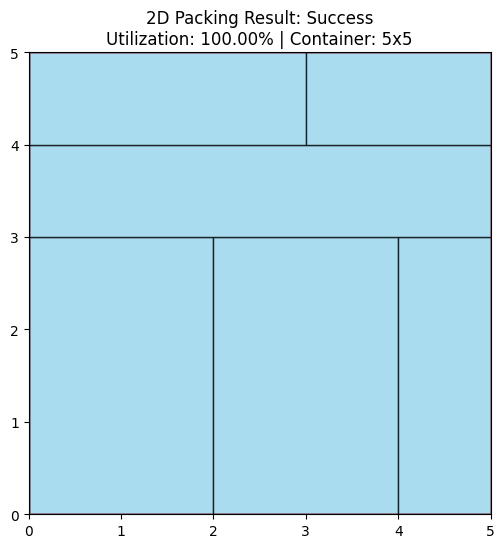

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

#計算空間利用率
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

def ffdh_packing_with_input():
    #輸入背包 M*N
    try:
        M = int(input("請輸入背包寬度 M: "))
        N = int(input("請輸入背包高度 N: "))
        num_items = int(input("請輸入物品總數: "))
    except ValueError:
        print("輸入錯誤！請確保輸入的是整數。")
        return

    #輸入每個物品的長寬
    items = []
    print(f"\n--- 請開始輸入 {num_items} 個物品的資訊 ---")
    for i in range(num_items):
        try:
            line = input(f"第 {i+1} 個物品的 [寬 高] (空白分隔): ")
            w, h = map(int, line.split())
            
            #過濾掉超過大小的物品 (這部分是你剛才想改的邏輯)
            if w <= M and h <= N:
                items.append((w, h))
            else:
                print(f"警告：物品 {w}x{h} 超出背包尺寸，已自動捨棄。")
        except ValueError:
            print("格式錯誤，跳過此物品。")

    #執行 FFDH 演算法
    sorted_items = sorted(items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    curr_x, curr_y = 0, 0
    shelf_h = 0
    can_fit_all = True
    
    for w, h in sorted_items:
        if curr_x + w > M:
            curr_y += shelf_h
            curr_x = 0
            shelf_h = 0
            
        if curr_y + h > N:
            can_fit_all = False
            continue #試試看後面的能不能塞進去
            
        placed_rects.append((curr_x, curr_y, w, h))
        curr_x += w
        shelf_h = max(shelf_h, h)

    #計算利用率
    rate = calculate_utilization(M, N, placed_rects)
    print(f"\n計算完成！目前空間利用率: {rate:.2f}%")

    #繪圖結果
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, M)
    ax.set_ylim(0, N)
    ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2, label='Backpack'))
    
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    for x, y, w, h in placed_rects:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='skyblue', edgecolor='black', alpha=0.7))
        
    status = "Success" if (can_fit_all and len(placed_rects) == len(items)) else "Failed"
    plt.title(f"2D Packing Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
    plt.show()

#啟動輸入流程
ffdh_packing_with_input()

開始執行 10000 次隨機測試...
設定背包大小為: 20x20



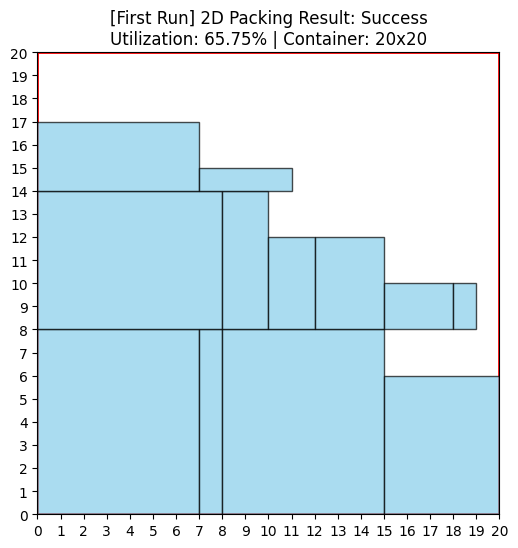

--- 實驗統計結果 ---
測試總筆數: 10000
平均空間利用率: 50.05%
完全成功裝入的機率: 92.17%


In [30]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

random.seed(68)

#計算空間利用率的函式
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

#FFDH演算法
def run_ffdh(M, N, items, draw_graph=False):
    #物品依高度降序排序
    sorted_items = sorted(items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    #shelves 紀錄每一層樓的資訊：[[當前可用_x, 起始_y, 該層天花板高度]]
    #一開始初始化第一層樓，從 (0, 0) 開始，天花板先設為 0
    shelves = [[0, 0, 0]] 
    can_fit_all = True
    
    for w, h in sorted_items:
        fit_found = False
        
        #從底層開始往上找，看哪一層的剩餘寬度放得下
        for i in range(len(shelves)):
            curr_x, curr_y, shelf_h = shelves[i]
            
            #如果這一層樓的寬度夠放這個物品
            if curr_x + w <= M:
                #檢查高度會不會戳破背包總高度
                if curr_y + h <= N:
                    placed_rects.append((curr_x, curr_y, w, h))
                    
                    #更新這層樓的下一個可用 X 座標
                    shelves[i][0] += w
                    #更新這層樓的天花板高度（由這層樓最高的物品決定）
                    shelves[i][2] = max(shelf_h, h)
                    
                    fit_found = True
                    break #成功放入這一層，跳出迴圈，換下一個物品
                    
        #如果遍歷了所有現有的樓層，都塞不下，開新層
        if not fit_found:
            #新樓層的起始 Y 座標，就是之前所有樓層的天花板高度總和
            last_x, last_y, last_h = shelves[-1]
            new_y = last_y + last_h
            
            #檢查新樓層的高度會不會超出背包
            if new_y + h <= N:
                placed_rects.append((0, new_y, w, h))
                #創立新樓層：下一個可用 X 是 w，起始 Y 是 new_y，本層初始天花板高度是 h
                shelves.append([w, new_y, h])
            else:
                #真的連頂樓都蓋不下去了，宣告失敗
                can_fit_all = False

    #計算利用率
    rate = calculate_utilization(M, N, placed_rects)
    
    #檢查是否所有「有效物品」都成功塞入
    #如果原本隨機生成的物品中有被自動捨棄的，或是裝不下的，皆視為該筆測試失敗
    is_success = can_fit_all and (len(placed_rects) == len(items))

    #只畫第一筆數據
    if draw_graph:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, M)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2, label='Backpack'))
        
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

        for x, y, w, h in placed_rects:
            ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='skyblue', edgecolor='black', alpha=0.7))
            
        status = "Success" if is_success else "Failed"
        plt.title(f"[First Run] 2D Packing Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
        plt.show()

    return rate, is_success

#模擬 1000 筆數據的主程式
def simulate_packing_experiment():
    #固定背包大小
    M, N = 20, 20  
    
    total_runs = 10000
    success_count = 0
    utilization_scores = []
    
    print(f"開始執行 {total_runs} 次隨機測試...")
    print(f"設定背包大小為: {M}x{N}\n")

    for i in range(total_runs):
        #---隨機生成單次測試的數據---
        #隨機決定這次要有幾個物品
        num_items = random.randint(5, 15) 
        
        items = []
        for _ in range(num_items):
            #隨機生成每個物品的寬與高
            w = random.randint(1, 8)
            h = random.randint(1, 8)
            items.append((w, h))
        
        #---執行演算法---
        #只畫第一筆數據
        is_first_run = (i == 0)
        rate, is_success = run_ffdh(M, N, items, draw_graph=is_first_run)
        
        #---紀錄統計結果---
        utilization_scores.append(rate)
        if is_success:
            success_count += 1

    #計算並列印平均結果
    avg_utilization = sum(utilization_scores) / total_runs
    success_rate = (success_count / total_runs) * 100

    print("--- 實驗統計結果 ---")
    print(f"測試總筆數: {total_runs}")
    print(f"平均空間利用率: {avg_utilization:.2f}%")
    print(f"完全成功裝入的機率: {success_rate:.2f}%")

#啟動實驗
simulate_packing_experiment()

開始執行 10000 次隨機測試...
設定背包大小為: 20x20



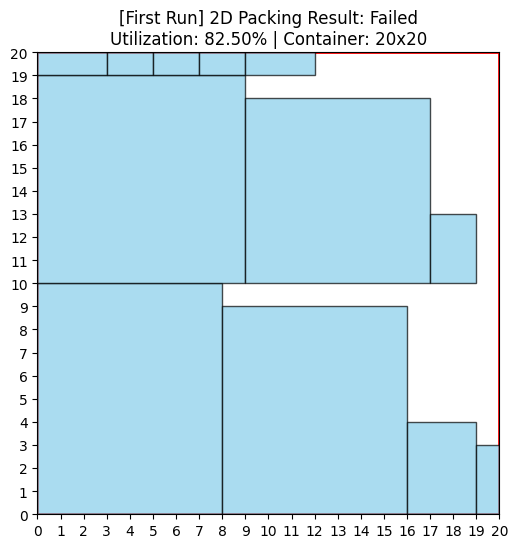

--- 實驗統計結果 ---
測試總筆數: 10000
平均空間利用率: 72.42%
完全成功裝入的機率: 53.56%


In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

random.seed(71)

#計算空間利用率的函式
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

#FFDH演算法
def run_ffdh(M, N, items, draw_graph=False):
    #物品依高度降序排序
    sorted_items = sorted(items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    #shelves 紀錄每一層樓的資訊：[[當前可用_x, 起始_y, 該層天花板高度]]
    #一開始初始化第一層樓，從 (0, 0) 開始，天花板先設為 0
    shelves = [[0, 0, 0]] 
    can_fit_all = True
    
    for w, h in sorted_items:
        fit_found = False
        
        #從底層開始往上找，看哪一層的剩餘寬度放得下
        for i in range(len(shelves)):
            curr_x, curr_y, shelf_h = shelves[i]
            
            #如果這一層樓的寬度夠放這個物品
            if curr_x + w <= M:
                #檢查高度會不會戳破背包總高度
                if curr_y + h <= N:
                    placed_rects.append((curr_x, curr_y, w, h))
                    
                    #更新這層樓的下一個可用 X 座標
                    shelves[i][0] += w
                    #更新這層樓的天花板高度（由這層樓最高的物品決定）
                    shelves[i][2] = max(shelf_h, h)
                    
                    fit_found = True
                    break #成功放入這一層，跳出迴圈，換下一個物品
                    
        #如果遍歷了所有現有的樓層，都塞不下，開新層
        if not fit_found:
            #新樓層的起始 Y 座標，就是之前所有樓層的天花板高度總和
            last_x, last_y, last_h = shelves[-1]
            new_y = last_y + last_h
            
            #檢查新樓層的高度會不會超出背包
            if new_y + h <= N:
                placed_rects.append((0, new_y, w, h))
                #創立新樓層：下一個可用 X 是 w，起始 Y 是 new_y，本層初始天花板高度是 h
                shelves.append([w, new_y, h])
            else:
                #真的連頂樓都蓋不下去了，宣告失敗
                can_fit_all = False

    #計算利用率
    rate = calculate_utilization(M, N, placed_rects)
    
    #檢查是否所有「有效物品」都成功塞入
    #如果原本隨機生成的物品中有被自動捨棄的，或是裝不下的，皆視為該筆測試失敗
    is_success = can_fit_all and (len(placed_rects) == len(items))

    #只畫第一筆數據
    if draw_graph:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, M)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2, label='Backpack'))
        
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

        for x, y, w, h in placed_rects:
            ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='skyblue', edgecolor='black', alpha=0.7))
            
        status = "Success" if is_success else "Failed"
        plt.title(f"[First Run] 2D Packing Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
        plt.show()

    return rate, is_success

#模擬 1000 筆數據的主程式
def simulate_packing_experiment():
    #固定背包大小
    M, N = 20, 20  
    
    total_runs = 10000
    success_count = 0
    utilization_scores = []
    
    print(f"開始執行 {total_runs} 次隨機測試...")
    print(f"設定背包大小為: {M}x{N}\n")

    for i in range(total_runs):
        #---隨機生成單次測試的數據---
        #隨機決定這次要有幾個物品
        num_small_items = random.randint(5, 15) 
        num_big_items = random.randint(2, 4) 
        
        items = []
        for _ in range(num_small_items):
            #隨機生成每個物品的寬與高
            w = random.randint(1, 4)
            h = random.randint(1, 4)
            items.append((w, h))

        for _ in range(num_big_items):
            #隨機生成每個物品的寬與高
            w = random.randint(8, 10)
            h = random.randint(8, 10)
            items.append((w, h))
        
        #---執行演算法---
        #只畫第一筆數據
        is_first_run = (i == 0)
        rate, is_success = run_ffdh(M, N, items, draw_graph=is_first_run)
        
        #---紀錄統計結果---
        utilization_scores.append(rate)
        if is_success:
            success_count += 1

    #計算並列印平均結果
    avg_utilization = sum(utilization_scores) / total_runs
    success_rate = (success_count / total_runs) * 100

    print("--- 實驗統計結果 ---")
    print(f"測試總筆數: {total_runs}")
    print(f"平均空間利用率: {avg_utilization:.2f}%")
    print(f"完全成功裝入的機率: {success_rate:.2f}%")

#啟動實驗
simulate_packing_experiment()


--- 請開始輸入 5 個物品的資訊 ---

計算完成！目前空間利用率: 100.00%


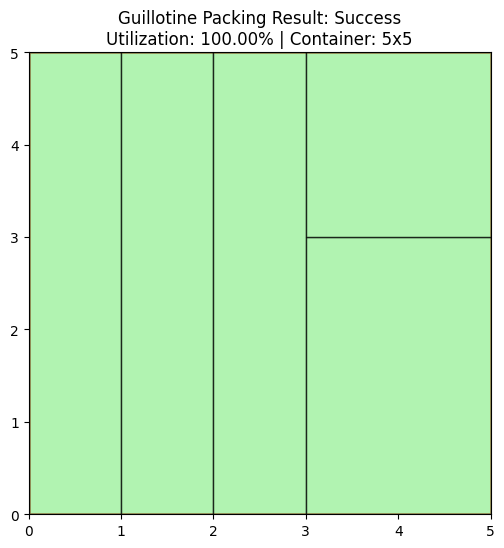

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

#計算空間利用率
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

def guillotine_packing_with_input():
    #輸入背包 M*N
    try:
        M = int(input("請輸入背包寬度 M: "))
        N = int(input("請輸入背包高度 N: "))
        num_items = int(input("請輸入物品總數: "))
    except ValueError:
        print("輸入錯誤！請確保輸入的是整數。")
        return

    #輸入每個物品的長寬
    items = []
    print(f"\n--- 請開始輸入 {num_items} 個物品的資訊 ---")
    for i in range(num_items):
        try:
            line = input(f"第 {i+1} 個物品的 [寬 高] (空白分隔): ")
            w, h = map(int, line.split())
            
            #過濾掉超過大小的物品
            if w <= M and h <= N:
                items.append((w, h))
            else:
                print(f"警告：物品 {w}x{h} 超出背包尺寸，已自動捨棄。")
        except ValueError:
            print("格式錯誤，跳過此物品。")

    #按照高度降序排列
    sorted_items = sorted(items, key=lambda x: x[1], reverse=True)
    
    #初始狀態：只有一個大空箱矩形 (x, y, width, height)
    free_rectangles = [(0, 0, M, N)]
    placed_rects = []
    can_fit_all = True
    
    #執行斷頭台演算法
    for w, h in sorted_items:
        fit_found = False
        
        #尋找第一個塞得下的空矩形 (First Fit 策略)
        for i, (rx, ry, rw, rh) in enumerate(free_rectangles):
            if w <= rw and h <= rh:
                #決定放置在此空矩形的左下角
                placed_rects.append((rx, ry, w, h))
                
                #將此空矩形從可用清單中移除
                free_rectangles.pop(i)
                
                #斷頭台切一刀，分裂成兩個新空矩形（採用水平切法）
                top_rect = (rx, ry + h, rw, rh - h)        #上方新矩形
                right_rect = (rx + w, ry, rw - w, h)       #右方新矩形（注意高度是 h，非 rh）
                
                #只有當寬高大於 0 時，才放回清單中避免無效碎片
                if top_rect[2] > 0 and top_rect[3] > 0:
                    free_rectangles.append(top_rect)
                if right_rect[2] > 0 and right_rect[3] > 0:
                    free_rectangles.append(right_rect)
                    
                fit_found = True
                break
        
        if not fit_found:
            can_fit_all = False

    #計算利用率
    rate = calculate_utilization(M, N, placed_rects)
    print(f"\n計算完成！目前空間利用率: {rate:.2f}%")

    #繪圖結果
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, M)
    ax.set_ylim(0, N)
    ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2, label='Backpack'))
    
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    #繪製成功放入的物品
    for x, y, w, h in placed_rects:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='lightgreen', edgecolor='black', alpha=0.7))
        
    status = "Success" if (can_fit_all and len(placed_rects) == len(items)) else "Failed"
    plt.title(f"Guillotine Packing Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
    plt.show()

#啟動輸入流程
guillotine_packing_with_input()

開始執行斷頭台演算法 10000 次隨機測試...


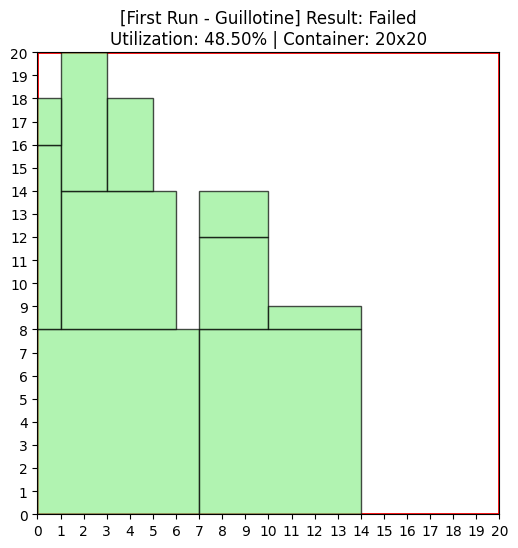


1000 次模擬實驗統計結果 (斷頭台)
平均空間利用率: 45.00%
成功率: 46.03%


In [28]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

random.seed(68)

#清空之前的圖表快取，防止環境卡死
plt.clf()
plt.close('all')

#計算空間利用率
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

#斷頭台演算法：橫向切割
def run_guillotine(M, N, items, draw_graph=False):
    #初始化空位清單，一開始只有一整個大背包
    #每個空位的格式為：[x, y, width, height]
    free_rects = [[0, 0, M, N]]
    
    #按照高度降序排列
    valid_items = [item for item in items if item[0] <= M and item[1] <= N]
    sorted_items = sorted(valid_items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    can_fit_all = True

    for w, h in sorted_items:
        best_idx = -1
        min_area = float('inf') #設一個無限大當初始值
        
        # --- 策略：Best-Area Fit (找尋能塞下該物品且面積最小的空位) ---
        for i, slot in enumerate(free_rects):
            slot_x, slot_y, slot_w, slot_h = slot
            if slot_w >= w and slot_h >= h:
                area = slot_w * slot_h
                if area < min_area:
                    min_area = area
                    best_idx = i
                    
        # --- 如果找到適合的空位 ---
        if best_idx != -1:
            #拿出這個最佳空位，並從清單中移除
            X, Y, W, H = free_rects.pop(best_idx)
            
            #紀錄物品擺放的位置
            placed_rects.append((X, Y, w, h))
            
            # --- 核心：斷頭台橫向切割 (Horizontal Split) ---
            #物品上方的空位
            top_box = [X, Y + h, w, H - h]
            #物品右方延伸到邊界的空位
            right_box = [X + w, Y, W - w, H]
            
            #如果切出來的小空位面積大於 0，就塞回空位清單供後續使用
            if top_box[2] > 0 and top_box[3] > 0:
                free_rects.append(top_box)
            if right_box[2] > 0 and right_box[3] > 0:
                free_rects.append(right_box)
        else:
            #翻遍了所有小空位都塞不進去，這顆物品宣告失敗
            can_fit_all = False

    #計算統計數據
    rate = calculate_utilization(M, N, placed_rects)
    is_success = can_fit_all and (len(placed_rects) == len(items))

    #第一筆數據繪圖
    if draw_graph:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, M)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        
        #畫背包邊框
        ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2))
        
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

        #畫放進去的物品
        for x, y, w, h in placed_rects:
            ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='lightgreen', edgecolor='black', alpha=0.7))
            
        status = "Success" if is_success else "Failed"
        plt.title(f"[First Run - Guillotine] Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
        plt.show()

    return rate, is_success

#實驗主程式：模擬 10000 次
def simulate_packing_experiment():
    M, N = 20, 20       #背包大小
    total_runs = 10000   #總實驗次數
    
    success_count = 0
    utilization_scores = []
    
    print(f"開始執行斷頭台演算法 {total_runs} 次隨機測試...")

    for i in range(total_runs):
        #隨機生成 5~15 個物品
        num_items = random.randint(5, 15) 
        items = [(random.randint(1, 8), random.randint(1, 8)) for _ in range(num_items)]
        
        #只有在第一筆數據時畫圖
        is_first_run = (i == 0)
        rate, is_success = run_guillotine(M, N, items, draw_graph=is_first_run)
        
        utilization_scores.append(rate)
        if is_success:
            success_count += 1

    #計算平均值
    avg_utilization = sum(utilization_scores) / total_runs
    success_rate = (success_count / total_runs) * 100

    print("\n" + "=" * 30)
    print("1000 次模擬實驗統計結果 (斷頭台)")
    print("=" * 30)
    print(f"平均空間利用率: {avg_utilization:.2f}%")
    print(f"成功率: {success_rate:.2f}%")
    print("=" * 30)

if __name__ == '__main__':
    simulate_packing_experiment()

開始執行斷頭台演算法 10000 次隨機測試...


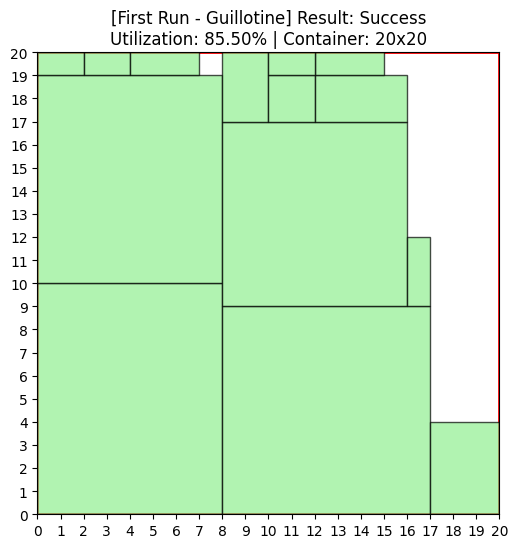


1000 次模擬實驗統計結果 (斷頭台)
平均空間利用率: 71.63%
成功率: 59.35%


In [26]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

random.seed(71)

#清空之前的圖表快取，防止環境卡死
plt.clf()
plt.close('all')

#計算空間利用率
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

#斷頭台演算法：橫向切割
def run_guillotine(M, N, items, draw_graph=False):
    #初始化空位清單，一開始只有一整個大背包
    #每個空位的格式為：[x, y, width, height]
    free_rects = [[0, 0, M, N]]
    
    #按照高度降序排列
    valid_items = [item for item in items if item[0] <= M and item[1] <= N]
    sorted_items = sorted(valid_items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    can_fit_all = True

    for w, h in sorted_items:
        best_idx = -1
        min_area = float('inf') #設一個無限大當初始值
        
        # --- 策略：Best-Area Fit (找尋能塞下該物品且面積最小的空位) ---
        for i, slot in enumerate(free_rects):
            slot_x, slot_y, slot_w, slot_h = slot
            if slot_w >= w and slot_h >= h:
                area = slot_w * slot_h
                if area < min_area:
                    min_area = area
                    best_idx = i
                    
        # --- 如果找到適合的空位 ---
        if best_idx != -1:
            #拿出這個最佳空位，並從清單中移除
            X, Y, W, H = free_rects.pop(best_idx)
            
            #紀錄物品擺放的位置
            placed_rects.append((X, Y, w, h))
            
            # --- 核心：斷頭台橫向切割 (Horizontal Split) ---
            #物品上方的空位
            top_box = [X, Y + h, w, H - h]
            #物品右方延伸到邊界的空位
            right_box = [X + w, Y, W - w, H]
            
            #如果切出來的小空位面積大於 0，就塞回空位清單供後續使用
            if top_box[2] > 0 and top_box[3] > 0:
                free_rects.append(top_box)
            if right_box[2] > 0 and right_box[3] > 0:
                free_rects.append(right_box)
        else:
            #翻遍了所有小空位都塞不進去，這顆物品宣告失敗
            can_fit_all = False

    #計算統計數據
    rate = calculate_utilization(M, N, placed_rects)
    is_success = can_fit_all and (len(placed_rects) == len(items))

    #第一筆數據繪圖
    if draw_graph:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, M)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        
        #畫背包邊框
        ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2))
        
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

        #畫放進去的物品
        for x, y, w, h in placed_rects:
            ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='lightgreen', edgecolor='black', alpha=0.7))
            
        status = "Success" if is_success else "Failed"
        plt.title(f"[First Run - Guillotine] Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
        plt.show()

    return rate, is_success

#實驗主程式：模擬 10000 次
def simulate_packing_experiment():
    M, N = 20, 20       #背包大小
    total_runs = 10000   #總實驗次數
    
    success_count = 0
    utilization_scores = []
    
    print(f"開始執行斷頭台演算法 {total_runs} 次隨機測試...")

    for i in range(total_runs):
        #隨機生成物品
        num_small_items = random.randint(5, 15) 
        num_big_items = random.randint(2, 4) 
        
        items = []
        for _ in range(num_small_items):
            #隨機生成每個物品的寬與高
            w = random.randint(1, 4)
            h = random.randint(1, 4)
            items.append((w, h))

        for _ in range(num_big_items):
            #隨機生成每個物品的寬與高
            w = random.randint(8, 10)
            h = random.randint(8, 10)
            items.append((w, h))
        
        #只有在第一筆數據時畫圖
        is_first_run = (i == 0)
        rate, is_success = run_guillotine(M, N, items, draw_graph=is_first_run)
        
        utilization_scores.append(rate)
        if is_success:
            success_count += 1

    #計算平均值
    avg_utilization = sum(utilization_scores) / total_runs
    success_rate = (success_count / total_runs) * 100

    print("\n" + "=" * 30)
    print("1000 次模擬實驗統計結果 (斷頭台)")
    print("=" * 30)
    print(f"平均空間利用率: {avg_utilization:.2f}%")
    print(f"成功率: {success_rate:.2f}%")
    print("=" * 30)

if __name__ == '__main__':
    simulate_packing_experiment()


--- 請開始輸入 6 個物品的資訊 ---

計算完成！目前空間利用率: 80.00%


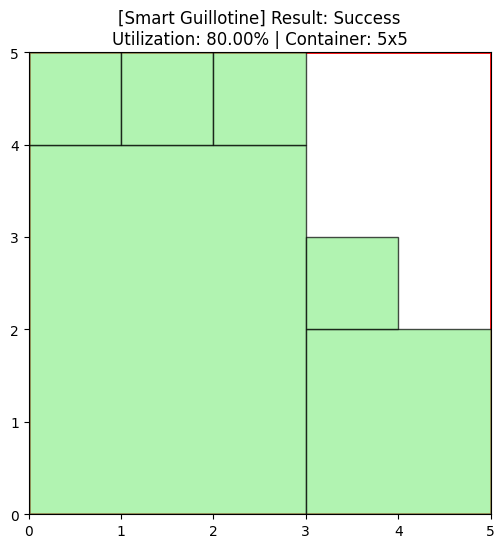

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

# 計算空間利用率
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

def smart_guillotine_packing_with_input():
    # 1. 輸入背包 M*N
    try:
        M = int(input("請輸入背包寬度 M: "))
        N = int(input("請輸入背包高度 N: "))
        num_items = int(input("請輸入物品總數: "))
    except ValueError:
        print("輸入錯誤！請確保輸入的是整數。")
        return

    # 2. 輸入每個物品的長寬
    items = []
    print(f"\n--- 請開始輸入 {num_items} 個物品的資訊 ---")
    for i in range(num_items):
        try:
            line = input(f"第 {i+1} 個物品的 [寬 高] (空白分隔): ")
            w, h = map(int, line.split())
            
            # 過濾掉超過大小的物品
            if w <= M and h <= N:
                items.append((w, h))
            else:
                print(f"警告：物品 {w}x{h} 超出背包尺寸，已自動捨棄。")
        except ValueError:
            print("格式錯誤，跳過此物品。")

    # 3. 排序：採用高度降序排序（跟你的 FFDH 一致，方便公平對比）
    sorted_items = sorted(items, key=lambda x: x[1], reverse=True)
    
    # 初始狀態：只有一個大空箱矩形 [x, y, width, height]
    free_rects = [[0, 0, M, N]]
    placed_rects = []
    can_fit_all = True
    
    # 4. 執行聰明的動態二分斷頭台演算法
    for w, h in sorted_items:
        best_idx = -1
        min_area = float('inf')
        
        # 策略：Best-Area Fit (在所有放得下的格子裡，挑面積最小的，避免浪費大格子)
        for i, slot in enumerate(free_rects):
            slot_x, slot_y, slot_w, slot_h = slot
            if slot_w >= w and slot_h >= h:
                area = slot_w * slot_h
                if area < min_area:
                    min_area = area
                    best_idx = i
                    
        # 如果找到適合的空位
        if best_idx != -1:
            X, Y, W, H = free_rects.pop(best_idx)
            placed_rects.append((X, Y, w, h))
            
            # 計算剩餘的寬高
            rem_w = W - w
            rem_h = H - h
            
            # --- 【核心優化：動態二分切割】 ---
            # 哪邊留下來的長度比較長，就往那邊切到底，確保剩下的格子最「方正」
            if rem_w > rem_h:
                # 垂直切：右邊切一刀大的到底
                top_box = [X, Y + h, w, rem_h]
                right_box = [X + w, Y, rem_w, H]
            else:
                # 水平切：上面切一刀大的到底
                top_box = [X, Y + h, W, rem_h]
                right_box = [X + w, Y, rem_w, h]
            
            # 只有當寬高大於 0 時，才放回清單中，防止無效的 0 面積格子卡住系統
            if top_box[2] > 0 and top_box[3] > 0:
                free_rects.append(top_box)
            if right_box[2] > 0 and right_box[3] > 0:
                free_rects.append(right_box)
        else:
            can_fit_all = False

    # 5. 計算利用率
    rate = calculate_utilization(M, N, placed_rects)
    print(f"\n計算完成！目前空間利用率: {rate:.2f}%")

    # 6. 繪圖結果
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, M)
    ax.set_ylim(0, N)
    ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2, label='Backpack'))
    
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    # 繪製成功放入的物品
    for x, y, w, h in placed_rects:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='lightgreen', edgecolor='black', alpha=0.7))
        
    status = "Success" if (can_fit_all and len(placed_rects) == len(items)) else "Failed"
    plt.title(f"[Smart Guillotine] Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
    plt.show()

# 啟動輸入流程
smart_guillotine_packing_with_input()

開始執行斷頭台演算法 10000 次隨機測試...


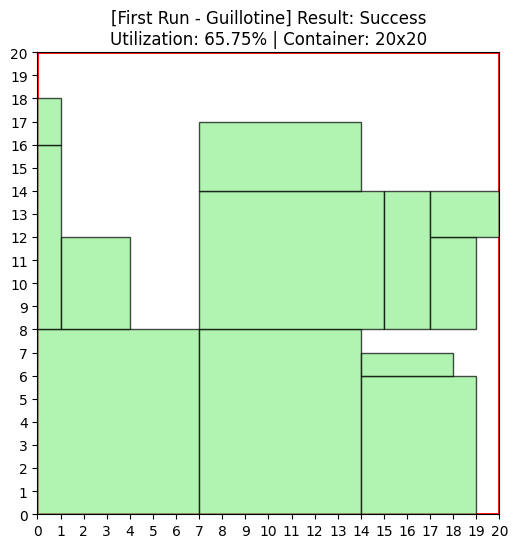


1000 次模擬實驗統計結果 (斷頭台)
平均空間利用率: 49.86%
成功率: 90.83%


In [13]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

random.seed(68)

#清空之前的圖表快取，防止環境卡死
plt.clf()
plt.close('all')

#計算空間利用率
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

#斷頭台演算法：動態切割
def run_guillotine(M, N, items, draw_graph=False):
    #初始化空位清單，一開始只有一整個大背包
    #每個空位的格式為：[x, y, width, height]
    free_rects = [[0, 0, M, N]]
    
    #按照物品高度降序排序
    valid_items = [item for item in items if item[0] <= M and item[1] <= N]
    sorted_items = sorted(valid_items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    can_fit_all = True

    for w, h in sorted_items:
        best_idx = -1
        min_area = float('inf') # 設一個無限大當初始值
        
        # --- 策略：Best-Area Fit (找尋能塞下該物品且面積最小的空位) ---
        for i, slot in enumerate(free_rects):
            slot_x, slot_y, slot_w, slot_h = slot
            if slot_w >= w and slot_h >= h:
                area = slot_w * slot_h
                if area < min_area:
                    min_area = area
                    best_idx = i
                    
        # --- 如果找到適合的空位 ---
        if best_idx != -1:
            #拿出這個最佳空位，並從清單中移除
            X, Y, W, H = free_rects.pop(best_idx)
            
            #紀錄物品擺放的位置
            placed_rects.append((X, Y, w, h))
            
            # --- 核心：聰明的斷頭台動態二分切割 (Guillotine Split) ---
            #剩餘的寬度和高度
            rem_w = W - w
            rem_h = H - h
            
            #策略：哪邊留下來的空間比較大，就往哪邊切到底（避免產生極端長條狀碎塊）
            if rem_w > rem_h:
                #垂直切：右邊切一刀大的到底
                top_box = [X, Y + h, w, rem_h]
                right_box = [X + w, Y, rem_w, H]
            else:
                #水平切：上面切一刀大的到底
                top_box = [X, Y + h, W, rem_h]
                right_box = [X + w, Y, rem_w, h]
            
            #只有當寬高大於 0 時，才放回清單中
            if top_box[2] > 0 and top_box[3] > 0:
                free_rects.append(top_box)
            if right_box[2] > 0 and right_box[3] > 0:
                free_rects.append(right_box)
            
        else:
            #翻遍了所有小空位都塞不進去，這顆物品宣告失敗
            can_fit_all = False

    #計算統計數據
    rate = calculate_utilization(M, N, placed_rects)
    is_success = can_fit_all and (len(placed_rects) == len(items))

    #第一筆數據繪圖
    if draw_graph:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, M)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        
        #畫背包邊框
        ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2))
        
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

        #畫放進去的物品
        for x, y, w, h in placed_rects:
            ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='lightgreen', edgecolor='black', alpha=0.7))
            
        status = "Success" if is_success else "Failed"
        plt.title(f"[First Run - Guillotine] Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
        plt.show()

    return rate, is_success

#實驗主程式：模擬 10000 次
def simulate_packing_experiment():
    M, N = 20, 20       #背包大小
    total_runs = 10000   #總實驗次數
    
    success_count = 0
    utilization_scores = []
    
    print(f"開始執行斷頭台演算法 {total_runs} 次隨機測試...")

    for i in range(total_runs):
        #隨機生成 5~15 個物品
        num_items = random.randint(5, 15) 
        items = [(random.randint(1, 8), random.randint(1, 8)) for _ in range(num_items)]
        
        #只有在第一筆數據時畫圖
        is_first_run = (i == 0)
        rate, is_success = run_guillotine(M, N, items, draw_graph=is_first_run)
        
        utilization_scores.append(rate)
        if is_success:
            success_count += 1

    #計算平均值
    avg_utilization = sum(utilization_scores) / total_runs
    success_rate = (success_count / total_runs) * 100

    print("\n" + "=" * 30)
    print("1000 次模擬實驗統計結果 (斷頭台)")
    print("=" * 30)
    print(f"平均空間利用率: {avg_utilization:.2f}%")
    print(f"成功率: {success_rate:.2f}%")
    print("=" * 30)

if __name__ == '__main__':
    simulate_packing_experiment()

開始執行斷頭台演算法 10000 次隨機測試...


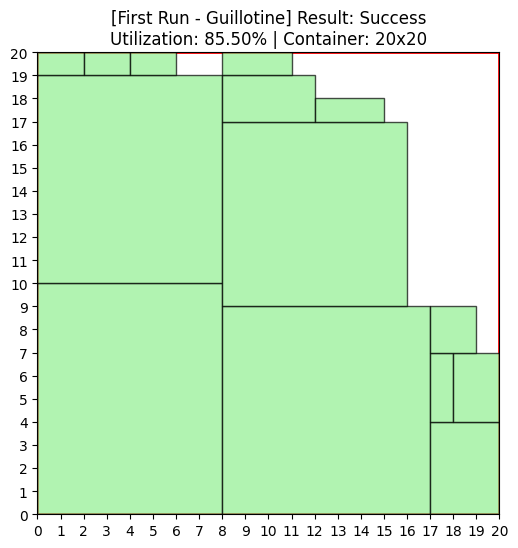


1000 次模擬實驗統計結果 (斷頭台)
平均空間利用率: 73.95%
成功率: 74.75%


In [27]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

random.seed(71)

#清空之前的圖表快取，防止環境卡死
plt.clf()
plt.close('all')

#計算空間利用率
def calculate_utilization(bin_w, bin_h, placed_rects):
    bin_area = bin_w * bin_h
    if bin_area == 0: return 0
    used_area = sum(w * h for x, y, w, h in placed_rects)
    return (used_area / bin_area) * 100

#斷頭台演算法：動態切割
def run_guillotine(M, N, items, draw_graph=False):
    #初始化空位清單，一開始只有一整個大背包
    #每個空位的格式為：[x, y, width, height]
    free_rects = [[0, 0, M, N]]
    
    #按照物品高度降序排序
    valid_items = [item for item in items if item[0] <= M and item[1] <= N]
    sorted_items = sorted(valid_items, key=lambda x: x[1], reverse=True)
    
    placed_rects = []
    can_fit_all = True

    for w, h in sorted_items:
        best_idx = -1
        min_area = float('inf') # 設一個無限大當初始值
        
        # --- 策略：Best-Area Fit (找尋能塞下該物品且面積最小的空位) ---
        for i, slot in enumerate(free_rects):
            slot_x, slot_y, slot_w, slot_h = slot
            if slot_w >= w and slot_h >= h:
                area = slot_w * slot_h
                if area < min_area:
                    min_area = area
                    best_idx = i
                    
        # --- 如果找到適合的空位 ---
        if best_idx != -1:
            #拿出這個最佳空位，並從清單中移除
            X, Y, W, H = free_rects.pop(best_idx)
            
            #紀錄物品擺放的位置
            placed_rects.append((X, Y, w, h))
            
            # --- 核心：聰明的斷頭台動態二分切割 (Guillotine Split) ---
            #剩餘的寬度和高度
            rem_w = W - w
            rem_h = H - h
            
            #策略：哪邊留下來的空間比較大，就往哪邊切到底（避免產生極端長條狀碎塊）
            if rem_w > rem_h:
                #垂直切：右邊切一刀大的到底
                top_box = [X, Y + h, w, rem_h]
                right_box = [X + w, Y, rem_w, H]
            else:
                #水平切：上面切一刀大的到底
                top_box = [X, Y + h, W, rem_h]
                right_box = [X + w, Y, rem_w, h]
            
            #只有當寬高大於 0 時，才放回清單中
            if top_box[2] > 0 and top_box[3] > 0:
                free_rects.append(top_box)
            if right_box[2] > 0 and right_box[3] > 0:
                free_rects.append(right_box)
            
        else:
            #翻遍了所有小空位都塞不進去，這顆物品宣告失敗
            can_fit_all = False

    #計算統計數據
    rate = calculate_utilization(M, N, placed_rects)
    is_success = can_fit_all and (len(placed_rects) == len(items))

    #第一筆數據繪圖
    if draw_graph:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, M)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        
        #畫背包邊框
        ax.add_patch(patches.Rectangle((0, 0), M, N, fill=None, edgecolor='red', linewidth=2))
        
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

        #畫放進去的物品
        for x, y, w, h in placed_rects:
            ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='lightgreen', edgecolor='black', alpha=0.7))
            
        status = "Success" if is_success else "Failed"
        plt.title(f"[First Run - Guillotine] Result: {status}\nUtilization: {rate:.2f}% | Container: {M}x{N}")
        plt.show()

    return rate, is_success

#實驗主程式：模擬 10000 次
def simulate_packing_experiment():
    M, N = 20, 20       #背包大小
    total_runs = 10000   #總實驗次數
    
    success_count = 0
    utilization_scores = []
    
    print(f"開始執行斷頭台演算法 {total_runs} 次隨機測試...")

    for i in range(total_runs):
        #隨機生成物品
        num_small_items = random.randint(5, 15) 
        num_big_items = random.randint(2, 4) 
        
        items = []
        for _ in range(num_small_items):
            #隨機生成每個物品的寬與高
            w = random.randint(1, 4)
            h = random.randint(1, 4)
            items.append((w, h))

        for _ in range(num_big_items):
            #隨機生成每個物品的寬與高
            w = random.randint(8, 10)
            h = random.randint(8, 10)
            items.append((w, h))
        
        #只有在第一筆數據時畫圖
        is_first_run = (i == 0)
        rate, is_success = run_guillotine(M, N, items, draw_graph=is_first_run)
        
        utilization_scores.append(rate)
        if is_success:
            success_count += 1

    #計算平均值
    avg_utilization = sum(utilization_scores) / total_runs
    success_rate = (success_count / total_runs) * 100

    print("\n" + "=" * 30)
    print("1000 次模擬實驗統計結果 (斷頭台)")
    print("=" * 30)
    print(f"平均空間利用率: {avg_utilization:.2f}%")
    print(f"成功率: {success_rate:.2f}%")
    print("=" * 30)

if __name__ == '__main__':
    simulate_packing_experiment()